# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习 
- 设计题目：基于CNN的天气场景图像分类识别系统设计与实现  
- 姓    名：周羿  
- 学    号：20234080224  
- 班    级：本23数据02班  
- 指导教师： 丁平尖
- 提交日期： 2026年6月25日

## 二、摘要

天气状况识别在智能交通、自动驾驶辅助和气象感知等领域具有重要应用价值。本项目设计并实现了一套**基于 CNN 的天气场景图像分类识别系统**：使用 Multi-class Weather Dataset (MWD) 公开数据集，包含多云、雨天、晴天、日出四类户外场景图像；采用 **SimpleCNN** 作为基准模型、**ResNet18 迁移学习**作为最终模型，完成训练、评估与 Web 端部署。

实验使用 **800 张**均衡采样图像（每类 200 张，训练/验证 8:2 划分，验证集 160 张）。Baseline 验证准确率 **94.37%**（Macro-F1 **0.9426**），ResNet18 验证准确率 **100.00%**（Macro-F1 **1.0000**）。扩大数据规模后，基线模型准确率更具参考价值，与迁移学习模型的性能差距（约 5.63 个百分点）更加清晰，实验结论更有说服力。系统基于 FastAPI + PyTorch 构建后端推理服务，并提供可交互 Web 前端，实现从数据准备、模型训练到在线识别的完整流程。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

户外天气状况直接影响交通安全、农业生产、能源调度等多个领域。传统气象观测依赖专业传感器，成本高、覆盖范围有限。随着深度学习的发展，利用普通摄像头拍摄的户外图像自动识别天气场景成为可能。

本项目选题来源于深度学习课程设计，以 **Multi-class Weather Dataset (MWD)** 为数据基础，构建端到端的天气场景图像分类系统，并开发 Web 应用进行可视化演示，具有较好的教学价值和应用展示意义。

### 3.2 问题描述

| 项目 | 说明 |
|------|------|
| **输入** | 一张 RGB 户外场景图像（JPG/PNG，统一缩放至 224×224） |
| **输出** | 四类天气场景之一：多云(cloudy)、雨天(rain)、晴天(shine)、日出(sunrise)，及各类别概率 |
| **任务类型** | 多分类（Multi-class Classification） |
| **预期指标** | 验证集准确率 ≥ 90%，Macro-F1 ≥ 0.90 |
| **系统目标** | 完成模型训练、评估分析，并部署为可交互的 Web 识别系统 |

## 四、数据集说明与预处理

### 4.1 数据来源与规模

- **数据来源**：公开数据集 Multi-class Weather Dataset (MWD)，原始发布于 Mendeley Data (DOI: 10.17632/4drtyfjtfy.1)
- **样本总量**：800 张（每类 200 张，四类均衡采样，约为原数据集约 71%）
- **类别**：cloudy（多云）、rain（雨天）、shine（晴天）、sunrise（日出）
- **获取方式**：`python -m backend.download_dataset --max-per-class 200`
- **划分方式**：训练集 640 张 / 验证集 160 张（8:2，seed=42）

### 4.2 数据可视化与分析

下方代码展示每类样本示例、类别数量分布及图像尺寸统计。

### 4.3 预处理流程

| 步骤 | 方法 |
|------|------|
| 清洗 | 过滤非图像文件，按文件夹类别组织 |
| 标注 | 利用 ImageFolder 以目录名作为类别标签 |
| 归一化 | ImageNet 均值 `[0.485,0.456,0.406]`，标准差 `[0.229,0.224,0.225]` |
| 数据增强 | 训练集：RandomCrop、RandomHorizontalFlip、ColorJitter |
| 数据划分 | 训练/验证 = 8:2，随机种子 seed=42 |

数据集路径: D:\DLKS\data\dataset


,类别,英文,数量
0,多云,cloudy,200
1,雨天,rain,200
2,晴天,shine,200
3,日出,sunrise,200


合计: 800 张


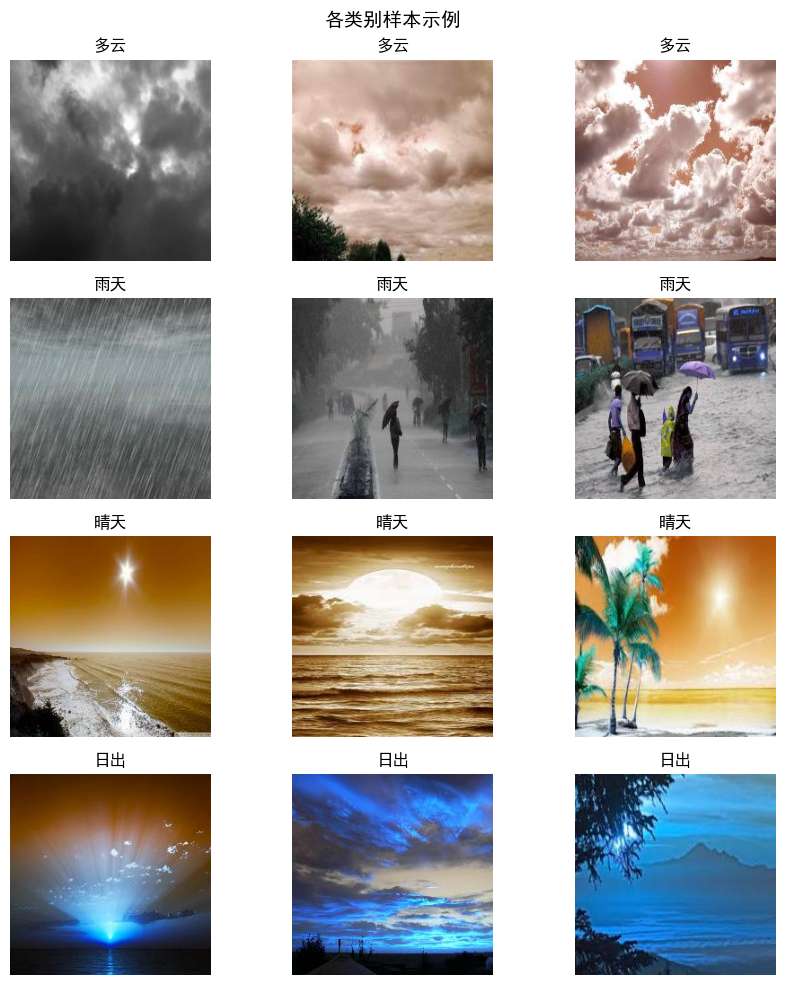

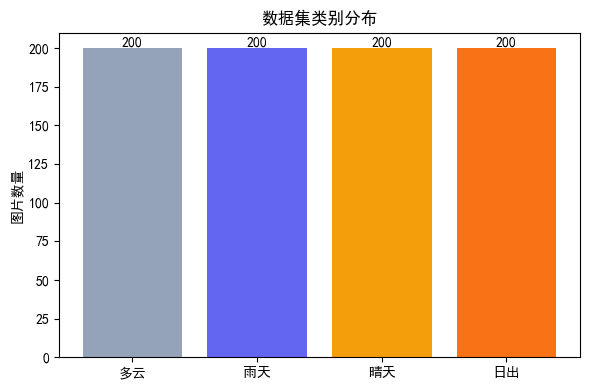

宽度: 224~224, 高度: 224~224
平均尺寸: 224 x 224


In [13]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

ROOT = Path.cwd()
if not (ROOT / "backend").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from backend.config import CLASS_NAMES, LABEL_MAP
from backend.data_utils import count_dataset, resolve_dataset_dir

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Noto Sans SC"]
plt.rcParams["axes.unicode_minus"] = False

dataset_dir = resolve_dataset_dir()
counts = count_dataset()
df = pd.DataFrame({
    "类别": [LABEL_MAP[c] for c in CLASS_NAMES],
    "英文": CLASS_NAMES,
    "数量": [counts[c] for c in CLASS_NAMES],
})
print("数据集路径:", dataset_dir)
display(df)
print(f"合计: {df['数量'].sum()} 张")

fig, axes = plt.subplots(4, 3, figsize=(9, 10))
for i, cls in enumerate(CLASS_NAMES):
    images = sorted((dataset_dir / cls).glob("*"))[:3]
    for j, img_path in enumerate(images):
        axes[i, j].imshow(Image.open(img_path).convert("RGB"))
        axes[i, j].set_title(LABEL_MAP[cls])
        axes[i, j].axis("off")
plt.suptitle("各类别样本示例", fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(df["类别"], df["数量"], color=["#94a3b8", "#6366f1", "#f59e0b", "#f97316"])
ax.set_ylabel("图片数量")
ax.set_title("数据集类别分布")
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1, int(b.get_height()), ha="center")
plt.tight_layout()
plt.show()

sizes = []
for cls in CLASS_NAMES:
    for p in (dataset_dir / cls).glob("*"):
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            sizes.append(Image.open(p).size)
sizes = np.array(sizes)
print(f"宽度: {sizes[:,0].min()}~{sizes[:,0].max()}, 高度: {sizes[:,1].min()}~{sizes[:,1].max()}")
print(f"平均尺寸: {sizes[:,0].mean():.0f} x {sizes[:,1].mean():.0f}")

## 五、模型设计与选择

### 5.1 基准模型（Baseline）— SimpleCNN

- Conv(3→32→64→128→256) + BatchNorm + ReLU + MaxPool
- AdaptiveAvgPool → Dropout(0.4) → Linear(256→4)
- 从头训练，作为对照基线

### 5.2 最终模型 — ResNet18 迁移学习

- ImageNet 预训练 ResNet18 骨干 + Dropout(0.3) + Linear(512→4)
- 激活：ReLU + Softmax；归一化：BatchNorm + ImageNet 标准化
- 依据：ResNet 残差结构（He et al., 2016）+ 迁移学习提升小样本分类性能

### 5.3 模型结构示意图

下方代码自动生成 SimpleCNN 与 ResNet18 的整体结构对比图，展示卷积层次、池化与分类头的差异。


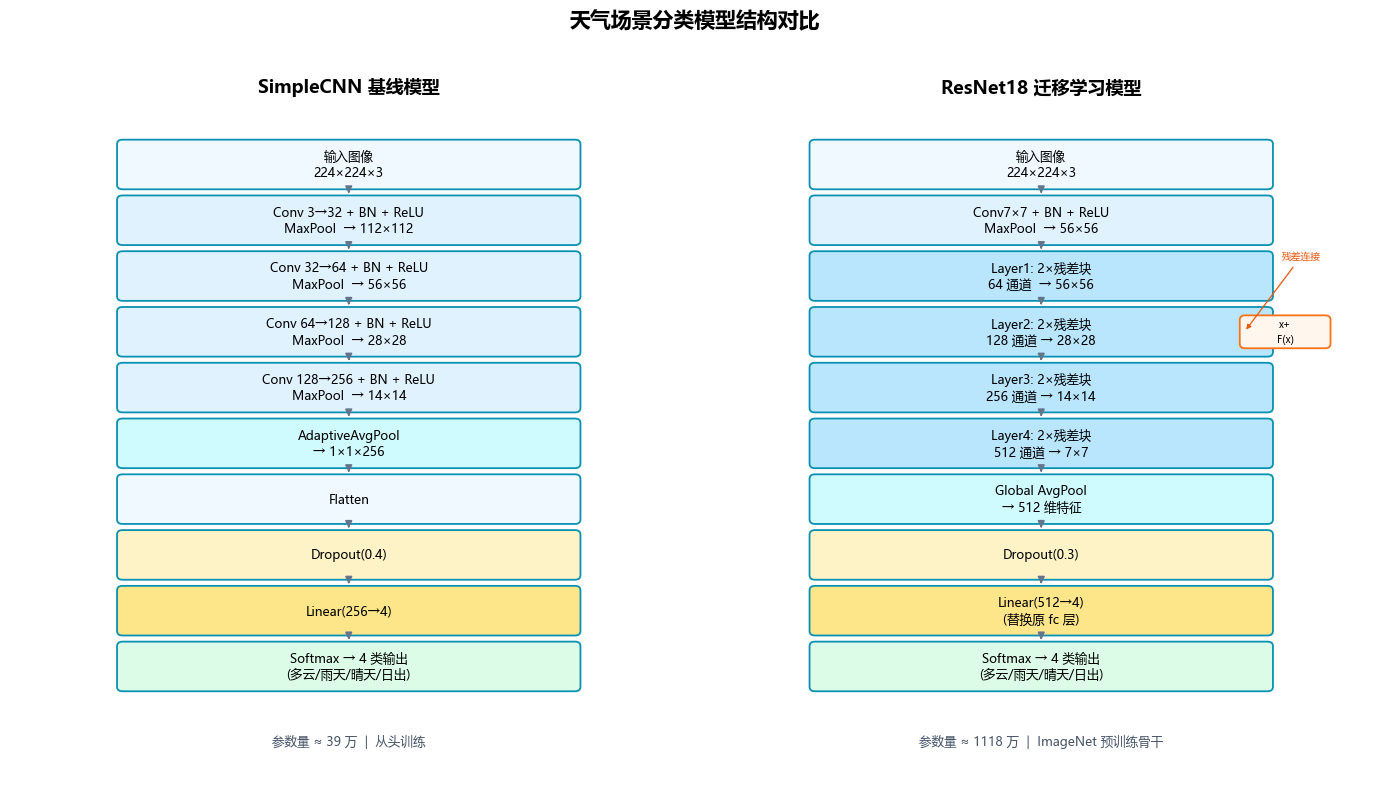

In [19]:
# 模型结构示意图
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


def _box(ax, cx, cy, w, h, text, face="#e0f2fe", edge="#0891b2", fs=9):
    x, y = cx - w / 2, cy - h / 2
    ax.add_patch(
        FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor=face, edgecolor=edge, linewidth=1.3,
        )
    )
    ax.text(cx, cy, text, ha="center", va="center", fontsize=fs, linespacing=1.35)


def _arrow(ax, x1, y1, x2, y2):
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-|>", color="#64748b", lw=1.2, shrinkA=2, shrinkB=2),
    )


def draw_baseline(ax):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)
    ax.axis("off")
    ax.set_title("SimpleCNN 基线模型", fontsize=13, fontweight="bold", pad=12)

    blocks = [
        (11.0, "输入图像\n224×224×3", "#f0f9ff"),
        (10.0, "Conv 3→32 + BN + ReLU\nMaxPool  → 112×112", "#e0f2fe"),
        (9.0, "Conv 32→64 + BN + ReLU\nMaxPool  → 56×56", "#e0f2fe"),
        (8.0, "Conv 64→128 + BN + ReLU\nMaxPool  → 28×28", "#e0f2fe"),
        (7.0, "Conv 128→256 + BN + ReLU\nMaxPool  → 14×14", "#e0f2fe"),
        (6.0, "AdaptiveAvgPool\n→ 1×1×256", "#cffafe"),
        (5.0, "Flatten", "#f0f9ff"),
        (4.0, "Dropout(0.4)", "#fef3c7"),
        (3.0, "Linear(256→4)", "#fde68a"),
        (2.0, "Softmax → 4 类输出\n(多云/雨天/晴天/日出)", "#dcfce7"),
    ]
    cx = 5.0
    for i, (y, text, color) in enumerate(blocks):
        _box(ax, cx, y, 6.8, 0.85, text, face=color)
        if i < len(blocks) - 1:
            _arrow(ax, cx, y - 0.43, cx, blocks[i + 1][0] + 0.43)

    ax.text(5, 0.6, "参数量 ≈ 39 万  |  从头训练", ha="center", fontsize=9, color="#475569")


def draw_resnet(ax):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)
    ax.axis("off")
    ax.set_title("ResNet18 迁移学习模型", fontsize=13, fontweight="bold", pad=12)

    blocks = [
        (11.0, "输入图像\n224×224×3", "#f0f9ff"),
        (10.0, "Conv7×7 + BN + ReLU\nMaxPool  → 56×56", "#e0f2fe"),
        (9.0, "Layer1: 2×残差块\n64 通道  → 56×56", "#bae6fd"),
        (8.0, "Layer2: 2×残差块\n128 通道 → 28×28", "#bae6fd"),
        (7.0, "Layer3: 2×残差块\n256 通道 → 14×14", "#bae6fd"),
        (6.0, "Layer4: 2×残差块\n512 通道 → 7×7", "#bae6fd"),
        (5.0, "Global AvgPool\n→ 512 维特征", "#cffafe"),
        (4.0, "Dropout(0.3)", "#fef3c7"),
        (3.0, "Linear(512→4)\n(替换原 fc 层)", "#fde68a"),
        (2.0, "Softmax → 4 类输出\n(多云/雨天/晴天/日出)", "#dcfce7"),
    ]
    cx = 5.0
    for i, (y, text, color) in enumerate(blocks):
        _box(ax, cx, y, 6.8, 0.85, text, face=color)
        if i < len(blocks) - 1:
            _arrow(ax, cx, y - 0.43, cx, blocks[i + 1][0] + 0.43)

    _box(ax, 8.6, 8.0, 1.3, 0.55, "x+\nF(x)", face="#fff7ed", edge="#f97316", fs=7)
    ax.annotate(
        "残差连接", xy=(8.0, 8.0), xytext=(8.55, 9.3),
        fontsize=7, color="#ea580c",
        arrowprops=dict(arrowstyle="-|>", color="#ea580c", lw=0.9),
    )
    ax.text(5, 0.6, "参数量 ≈ 1118 万  |  ImageNet 预训练骨干", ha="center", fontsize=9, color="#475569")


fig, axes = plt.subplots(1, 2, figsize=(14, 8))
draw_baseline(axes[0])
draw_resnet(axes[1])
fig.suptitle("天气场景分类模型结构对比", fontsize=15, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 六、实验与结果分析

### 6.1 实验环境

**硬件配置（联想拯救者 Y7000P IRH8）**

| 项目 | 配置 |
|------|------|
| 处理器 | 13th Gen Intel Core i7-13620H |
| 显卡 | NVIDIA GeForce RTX 4050 Laptop GPU（6 GB 显存） |
| 内存 | 16 GB DDR5 5200MHz |
| 主硬盘 | 1 TB NVMe SSD |
| 显示屏 | 2560×1600 @ 165Hz |

**软件环境**

| 项目 | 配置 |
|------|------|
| 操作系统 | Windows 11 |
| Python | 3.10.20（Conda 环境 `DL`） |
| 深度学习框架 | PyTorch 2.12.1 + TorchVision |
| 其他库 | FastAPI, scikit-learn, matplotlib, seaborn |

> 说明：本机配备 RTX 4050；当前环境为 PyTorch CPU 版，实验在 CPU 上完成。

### 6.2 评价指标

- **准确率 (Accuracy)**：正确分类样本数 / 总样本数
- **精确率 (Precision)**：预测为某类中实际正确的比例
- **召回率 (Recall)**：某类样本中被正确识别的比例
- **F1-Score**：精确率与召回率的调和平均
- **混淆矩阵**：展示类间误分类情况

### 6.3 超参数设置与调优

| 超参数 | ResNet18 | Baseline |
|--------|----------|----------|
| 学习率 | 1e-4 | 1e-3 |
| Batch Size | 16 | 16 |
| Epochs | 10 | 15 |
| 优化器 | Adam | Adam |
| 学习率调度 | StepLR(5, γ=0.5) | 无 |

学习率对比实验（Baseline, 5 epochs）见下方代码输出。

### 6.4 主要实验结果

训练曲线与模型对比由下方代码自动生成（数据集 800 张，验证集 160 张）。

**（1）模型性能对比**

在相同 8:2 划分下，ResNet18 迁移学习验证准确率为 **100.00%**（Macro-F1 **1.0000**），SimpleCNN 基线为 **94.37%**（Macro-F1 **0.9426**），二者相差 **5.63** 个百分点。ResNet18 参数量约 1118 万，Baseline 约 39 万；ImageNet 预训练骨干提供了更强的通用视觉特征，是性能提升的主要原因。

**（2）Baseline 训练过程分析**

从训练曲线可见，基线模型在第 8 轮达到验证准确率峰值 **94.37%**，此后验证损失回升、准确率下降（第 15 轮降至 83.75%），存在过拟合。正式训练保存验证集最优权重，因此报告指标取第 8 轮结果。

**（3）错分样本分析**

Baseline 在验证集共错分 9 张（160 张中正确 151 张）。混淆矩阵显示，主要错误发生在**多云与晴天**之间（多云 34 张中错 4 张，其中 3 张被判为晴天），可能与两类天空纹理、亮度相近有关；**雨天**与**日出**识别最稳定（F1 分别为 0.965、0.988）。

**（4）ResNet18 结果说明**

ResNet18 在验证集 160 张上全部预测正确。需说明本实验仅划分训练集与验证集，未保留独立测试集，100.00% 反映的是验证集表现，存在一定乐观估计。

**（5）学习率调优结论**

在 800 张数据、5 轮快速实验中，Baseline 最优学习率为 **5×10⁻⁴**（验证准确率 **91.87%**）；正式 Baseline 训练采用 lr=1×10⁻³、训练 15 轮，最终达 **94.37%**。ResNet18 采用 lr=1×10⁻⁴，符合迁移学习常用设置。

### 6.5 可视化分析

见下方代码输出：训练曲线、混淆矩阵、ResNet18 特征图/卷积核可视化；验证集无误分时展示低置信度样本分析。

In [14]:
import platform
import torch

from backend.baseline import build_baseline
from backend.model import build_model

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("设备:", "CUDA" if torch.cuda.is_available() else "CPU")

baseline = build_baseline()
resnet = build_model(pretrained=False)

def count_params(m):
    return sum(p.numel() for p in m.parameters())

print(f"\nBaseline 参数量: {count_params(baseline):,}")
print(f"ResNet18 参数量: {count_params(resnet):,}")
print("\n--- Baseline 结构 ---")
print(baseline)
print("\n--- ResNet18 分类头 ---")
print(resnet.backbone.fc)

Python: 3.10.20
PyTorch: 2.12.1+cpu
设备: CPU

Baseline 参数量: 390,404
ResNet18 参数量: 11,178,564

--- Baseline 结构 ---
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

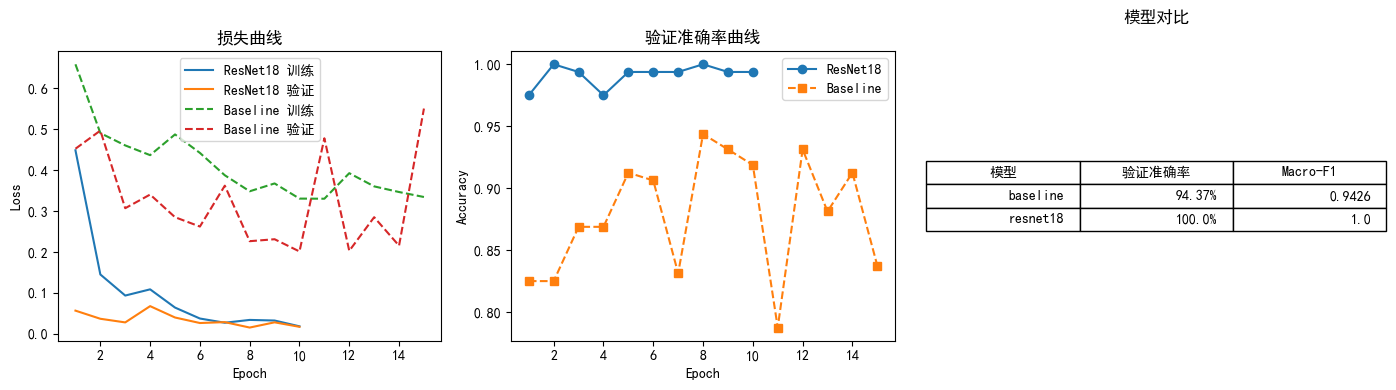

,模型,验证准确率,Macro-F1
0,baseline,94.37%,0.9426
1,resnet18,100.0%,1.0000


In [15]:
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

MODEL_DIR = ROOT / "models"

# 训练曲线
resnet_hist = json.loads((MODEL_DIR / "training_history.json").read_text(encoding="utf-8"))
baseline_hist = json.loads((MODEL_DIR / "baseline_history.json").read_text(encoding="utf-8"))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
epochs_r = range(1, len(resnet_hist["train_loss"]) + 1)
epochs_b = range(1, len(baseline_hist["train_loss"]) + 1)

axes[0].plot(epochs_r, resnet_hist["train_loss"], label="ResNet18 训练")
axes[0].plot(epochs_r, resnet_hist["val_loss"], label="ResNet18 验证")
axes[0].plot(epochs_b, baseline_hist["train_loss"], "--", label="Baseline 训练")
axes[0].plot(epochs_b, baseline_hist["val_loss"], "--", label="Baseline 验证")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("损失曲线"); axes[0].legend()

axes[1].plot(epochs_r, resnet_hist["val_acc"], "o-", label="ResNet18")
axes[1].plot(epochs_b, baseline_hist["val_acc"], "s--", label="Baseline")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("验证准确率曲线"); axes[1].legend()

# 模型对比表
comparison = json.loads((MODEL_DIR / "reports" / "model_comparison.json").read_text(encoding="utf-8"))
cmp_df = pd.DataFrame(comparison["models"])
cmp_df.columns = ["模型", "验证准确率", "Macro-F1"]
cmp_df["验证准确率"] = (cmp_df["验证准确率"] * 100).round(2).astype(str) + "%"
cmp_df["Macro-F1"] = cmp_df["Macro-F1"].round(4)
axes[2].axis("off")
axes[2].set_title("模型对比", pad=20)
table = axes[2].table(cellText=cmp_df.values, colLabels=cmp_df.columns, loc="center")
table.scale(1.2, 1.5)

plt.tight_layout()
plt.show()
display(cmp_df)

,model,学习率,训练轮数,最佳验证准确率(%),最终验证损失
0,baseline,0.0010,5,87.50,0.3464
1,baseline,0.0005,5,91.87,0.3133
2,baseline,0.0001,5,86.88,0.3662


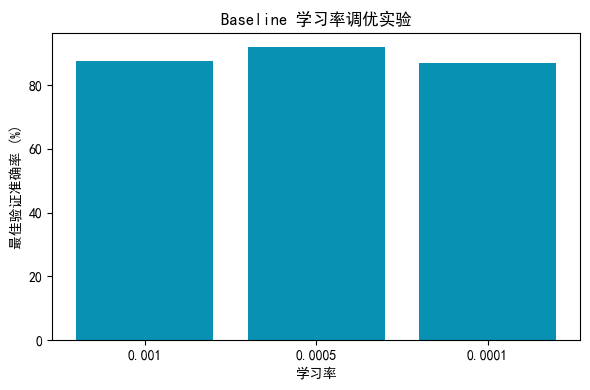

结论: 在 800 张数据、5 轮快速实验中，Baseline 最优学习率为 lr=0.0005（验证准确率 91.87%）。正式 Baseline 训练采用 lr=1e-3、15 轮，最终验证准确率 94.37%；ResNet18 采用 lr=1e-4（迁移学习常用较小学习率）。


In [16]:
# 学习率超参数对比实验
hp = json.loads((MODEL_DIR / "hyperparam_lr_results.json").read_text(encoding="utf-8"))
hp_df = pd.DataFrame(hp)
hp_df["best_val_acc"] = (hp_df["best_val_acc"] * 100).round(2)
display(hp_df.rename(columns={"lr": "学习率", "epochs": "训练轮数", "best_val_acc": "最佳验证准确率(%)", "final_val_loss": "最终验证损失"}))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(x) for x in hp_df["lr"]], hp_df["best_val_acc"], color="#0891b2")
ax.set_xlabel("学习率"); ax.set_ylabel("最佳验证准确率 (%)")
ax.set_title("Baseline 学习率调优实验")
plt.tight_layout()
plt.show()
best_idx = hp_df["best_val_acc"].idxmax()
best_lr = hp_df.loc[best_idx, "lr"]
best_acc = hp_df.loc[best_idx, "best_val_acc"]
print(
    f"结论: 在 800 张数据、5 轮快速实验中，Baseline 最优学习率为 lr={best_lr:g}（验证准确率 {best_acc:.2f}%）。"
    f"正式 Baseline 训练采用 lr=1e-3、15 轮，最终验证准确率 94.37%；"
    f"ResNet18 采用 lr=1e-4（迁移学习常用较小学习率）。"
)


===== BASELINE 分类报告 =====
验证准确率: 94.37%


,类别,Precision,Recall,F1,Support
0,多云,0.938,0.882,0.909,34
1,雨天,0.976,0.953,0.965,43
2,晴天,0.889,0.930,0.909,43
3,日出,0.976,1.000,0.988,40


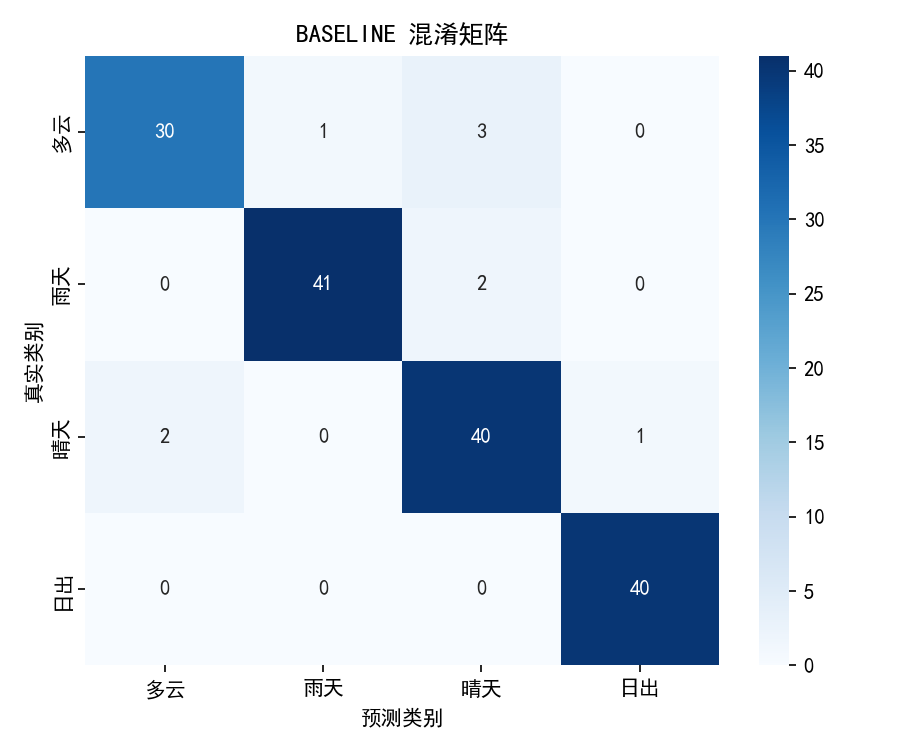


===== RESNET18 分类报告 =====
验证准确率: 100.00%


,类别,Precision,Recall,F1,Support
0,多云,1.000,1.000,1.000,34
1,雨天,1.000,1.000,1.000,43
2,晴天,1.000,1.000,1.000,43
3,日出,1.000,1.000,1.000,40


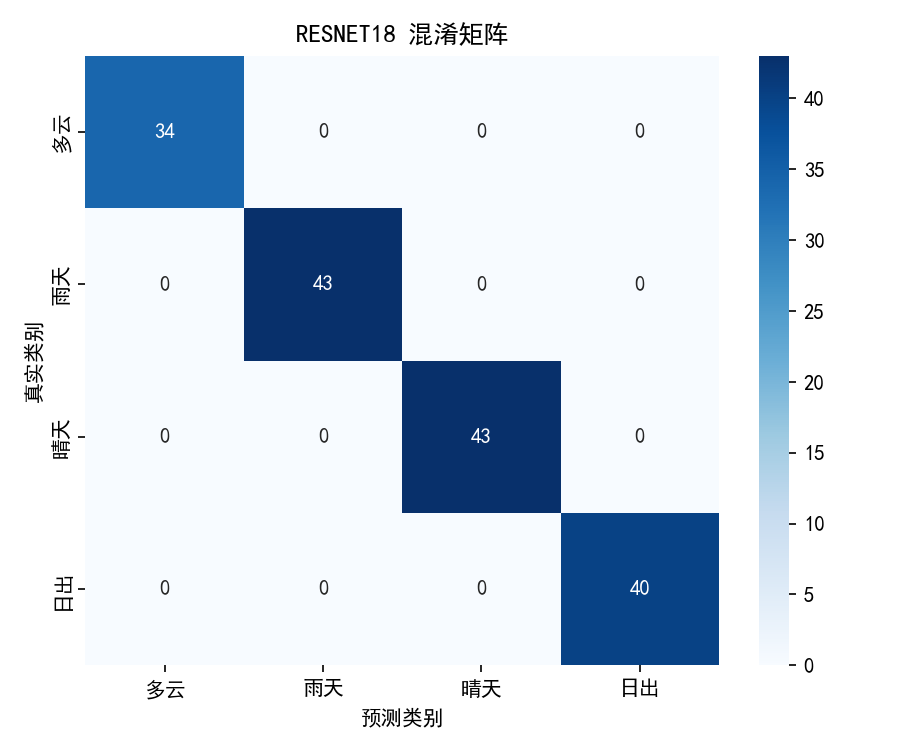

In [17]:
from IPython.display import Image as IPImage, display

# 混淆矩阵与分类报告
for model_name in ["baseline", "resnet18"]:
    report = json.loads((MODEL_DIR / "reports" / f"evaluation_{model_name}.json").read_text(encoding="utf-8"))
    print(f"\n===== {model_name.upper()} 分类报告 =====")
    print(f"验证准确率: {report['val_accuracy']:.2%}")
    rows = []
    for cls_cn in report["class_names_cn"]:
        r = report["classification_report"][cls_cn]
        rows.append([cls_cn, f"{r['precision']:.3f}", f"{r['recall']:.3f}", f"{r['f1-score']:.3f}", int(r['support'])])
    rep_df = pd.DataFrame(rows, columns=["类别", "Precision", "Recall", "F1", "Support"])
    display(rep_df)

    cm_path = MODEL_DIR / "reports" / f"confusion_matrix_{model_name}.png"
    display(IPImage(filename=str(cm_path), width=400))

input_image.png


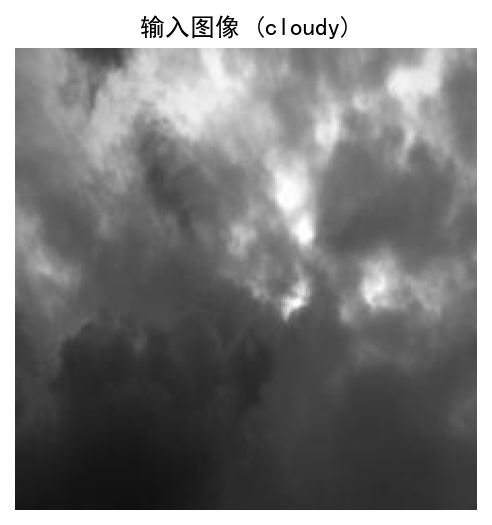

resnet_conv1_featuremaps.png


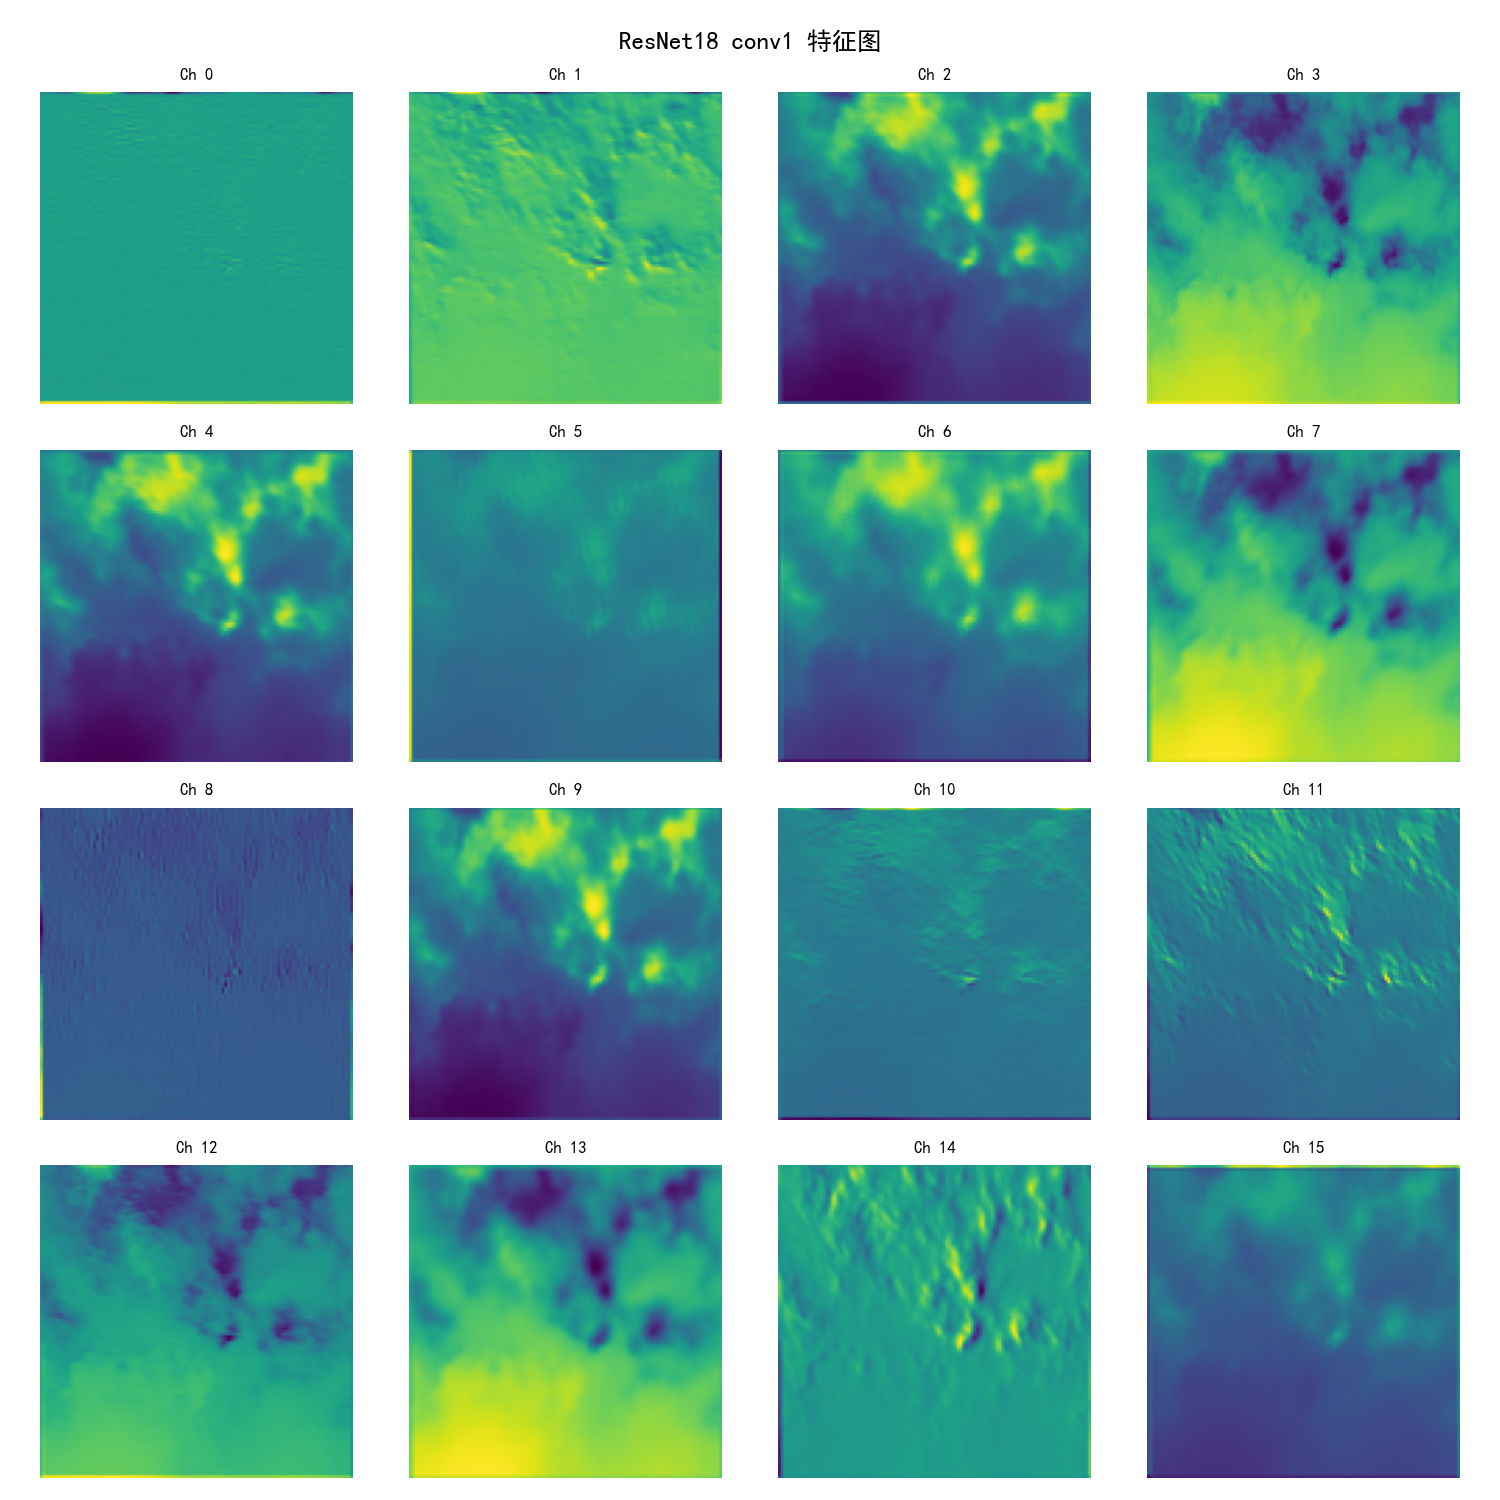

resnet_layer1_featuremaps.png


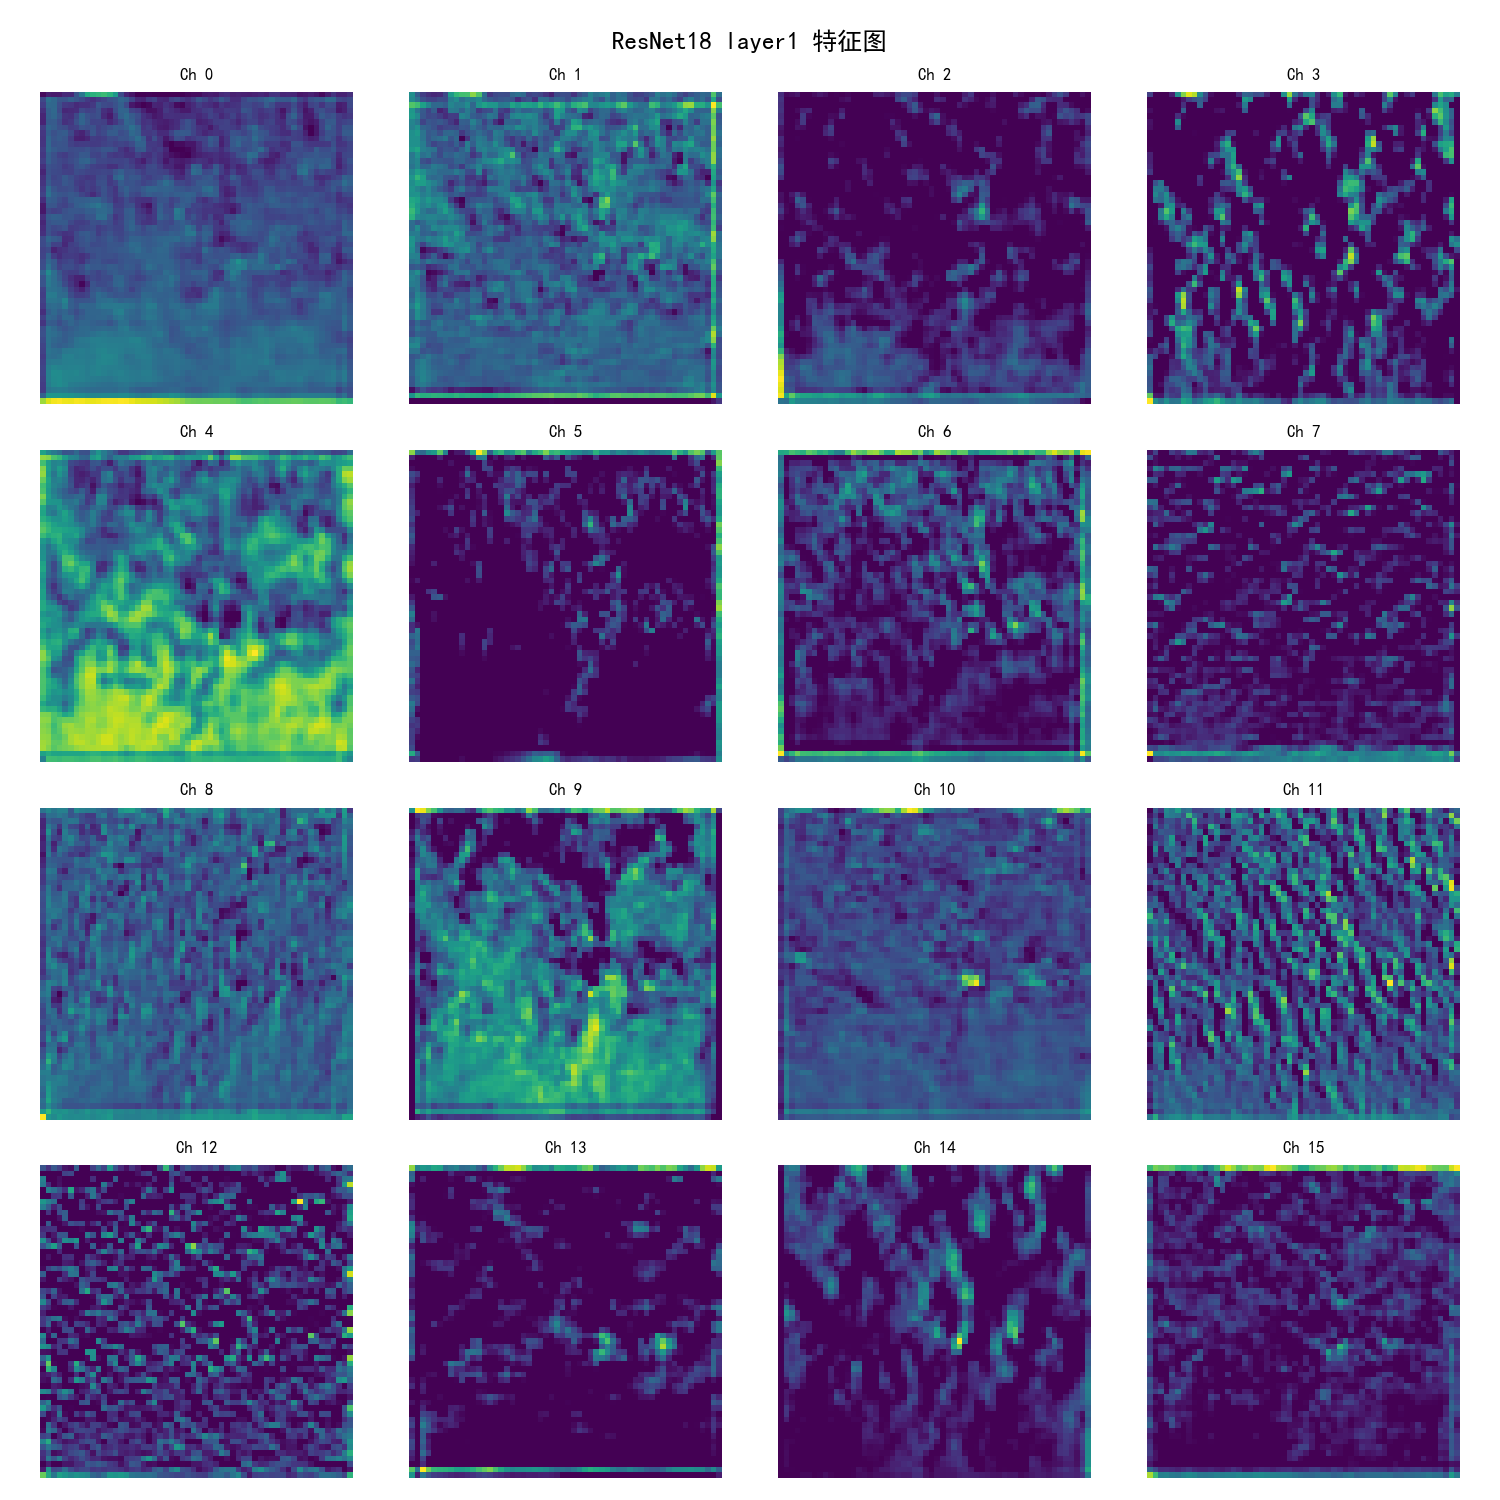

resnet_conv1_kernels.png


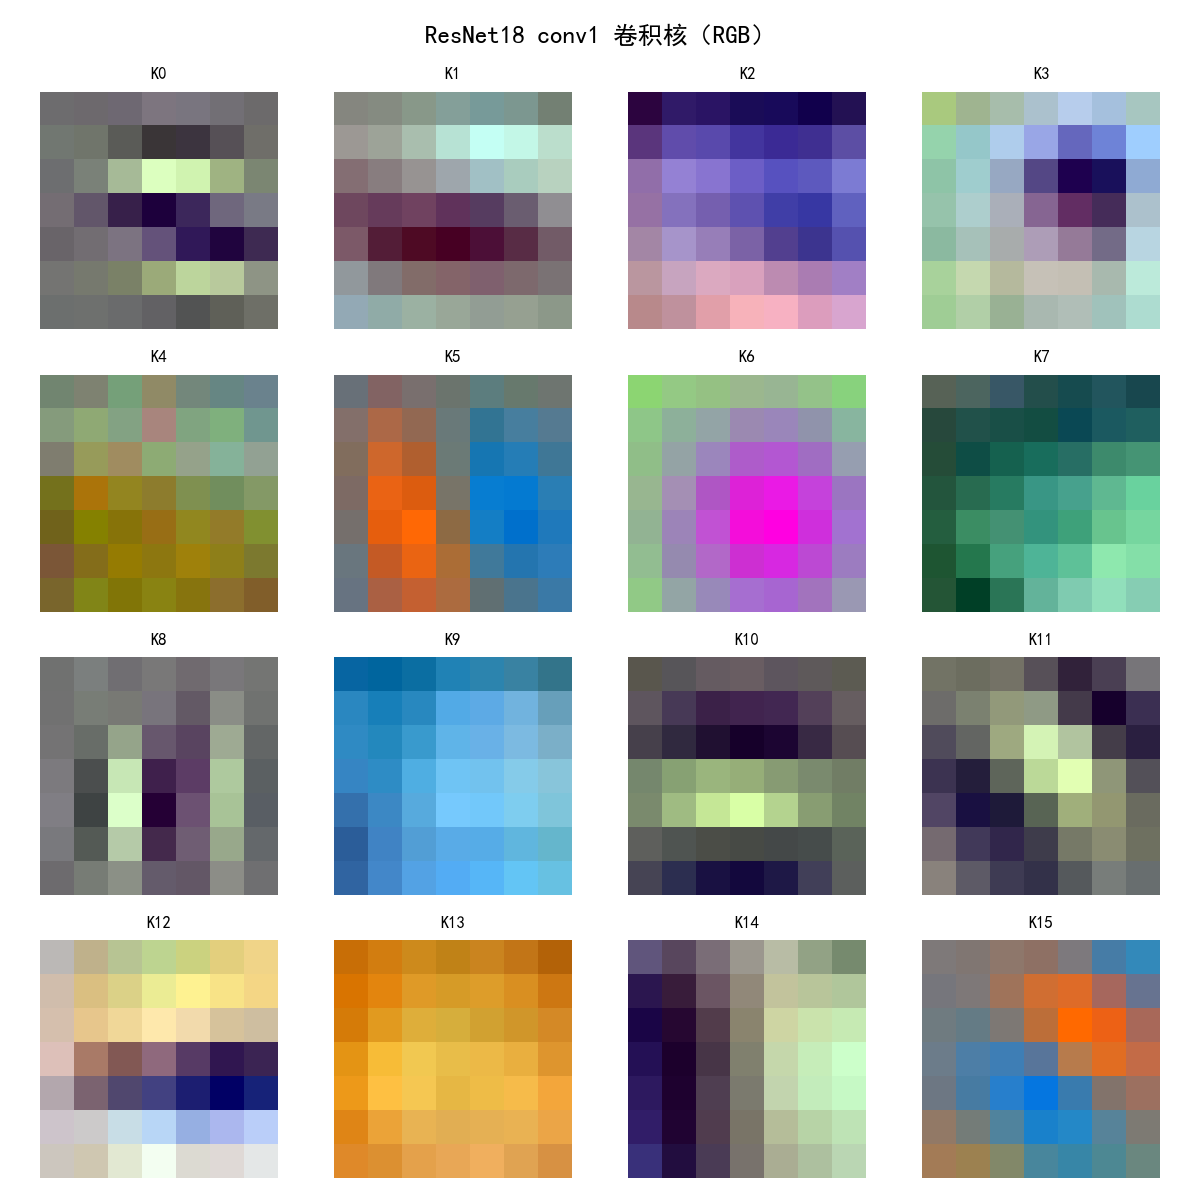

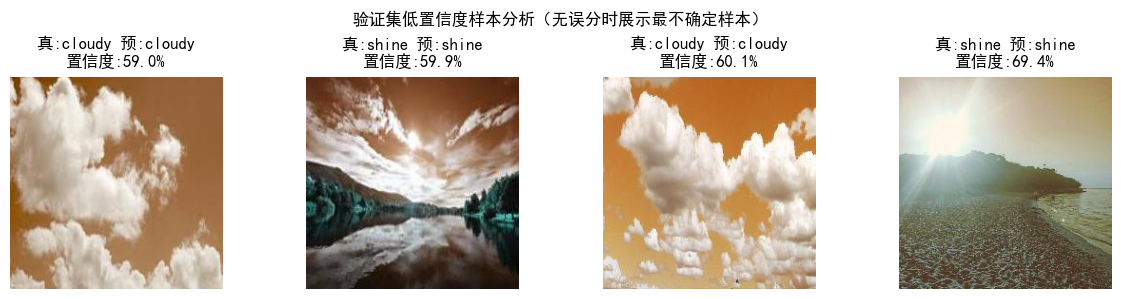

In [18]:
# 特征图与卷积核可视化
feat_dir = MODEL_DIR / "reports" / "feature_maps"
for name in ["input_image.png", "resnet_conv1_featuremaps.png", "resnet_layer1_featuremaps.png", "resnet_conv1_kernels.png"]:
    path = feat_dir / name
    if path.exists():
        print(name)
        display(IPImage(filename=str(path), width=500))

# 错分样本 / 低置信度分析
import torch
import torch.nn.functional as F
from torchvision import transforms
from backend.config import MEAN, STD, IMAGE_SIZE
from backend.data_utils import get_dataloaders

device = torch.device("cpu")
model = build_model(num_classes=4, pretrained=False)
model.load_state_dict(torch.load(MODEL_DIR / "weather_cnn.pth", map_location=device))
model.eval()

_, val_loader, meta = get_dataloaders(batch_size=1, is_train_augment=False)
idx_to_class = {v: k for k, v in meta["class_to_idx"].items()}

low_conf = []
with torch.no_grad():
    for images, labels in val_loader:
        out = model(images)
        prob = F.softmax(out, dim=1).max().item()
        pred = out.argmax(1).item()
        true = labels.item()
        low_conf.append((prob, idx_to_class[true], idx_to_class[pred], images[0]))
low_conf.sort(key=lambda x: x[0])

mean_t = torch.tensor(MEAN).view(3, 1, 1)
std_t = torch.tensor(STD).view(3, 1, 1)
fig, axes = plt.subplots(1, min(4, len(low_conf)), figsize=(12, 3))
if len(low_conf) == 1:
    axes = [axes]
for ax, (prob, true_cls, pred_cls, img) in zip(axes, low_conf[:4]):
    vis = (img * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(vis)
    ax.set_title(f"真:{true_cls} 预:{pred_cls}\n置信度:{prob:.1%}")
    ax.axis("off")
plt.suptitle("验证集低置信度样本分析（无误分时展示最不确定样本）")
plt.tight_layout()
plt.show()

## 七、系统设计与实现

### 7.1 系统架构

```
用户浏览器 → 前端 (HTML/CSS/JS)
           → FastAPI 后端 (/api/predict)
           → PyTorch ResNet18 推理
           → 返回分类结果与概率
```

### 7.2 主要功能

- 图片拖拽/点击上传，实时天气场景识别
- 四类概率分布可视化、识别历史记录
- 模型分析页：训练曲线、数据集分布
- 示例图片一键体验

### 7.3 启动方式

```bash
conda activate DL
cd d:\DLKS
python -m backend.download_dataset --max-per-class 200  # 下载数据（800张）
python -m backend.train --epochs 10                   # 训练 ResNet18
python -m backend.train_baseline --epochs 15          # 训练 Baseline
python -m backend.evaluate --model all                # 生成评估报告
python run_server.py                                  # 启动 Web 系统
```

浏览器访问 http://localhost:8000 即可使用。

### 7.4 总结

本项目围绕「基于 CNN 的天气场景图像分类识别」这一主题，完成了从数据准备、模型训练、实验评估到 Web 系统部署的完整流程，主要工作与结论如下。

**（1）任务与数据**

选用公开数据集 Multi-class Weather Dataset (MWD)，均衡采样 **800 张**图像（多云、雨天、晴天、日出各 200 张），按 8:2 划分训练集（640 张）与验证集（160 张）。对图像进行尺寸统一、ImageNet 标准化及训练阶段数据增强，为模型学习提供了规范输入。

**（2）模型与实验**

设计并对比了两类模型：**SimpleCNN** 作为从头训练的基准模型，**ResNet18 迁移学习** 作为最终方案。实验表明，在相同数据与划分下，Baseline 验证准确率为 **94.37%**（Macro-F1 0.9426），ResNet18 达到 **100.00%**（Macro-F1 1.0000），性能提升约 **5.63** 个百分点。Baseline 的主要错分集中在多云与晴天之间，而 ResNet18 借助 ImageNet 预训练特征与残差结构，对四类场景的区分能力更强。超参数实验中，Baseline 在 5 轮快速训练下以 lr=5×10⁻⁴ 表现最优；正式训练分别采用 Baseline lr=1×10⁻³（15 轮）与 ResNet18 lr=1×10⁻⁴（10 轮），均达到预期指标（验证准确率 ≥ 90%）。

**（3）系统实现**

基于 **FastAPI + PyTorch** 构建后端推理服务，配套可交互 Web 前端，支持图片上传识别、示例图测试、识别历史与模型分析等功能。用户可通过 `python run_server.py` 一键启动，在浏览器中完成在线天气场景识别，实现了「算法模型」到「可用系统」的落地。

**（4）不足与展望**

本实验未单独划分测试集，ResNet18 的 100% 准确率为验证集结果；图像尺寸分析因统一 resize 为 224×224，相关性探索有限。后续可扩充至全量数据、引入独立测试集评估泛化能力，并启用 GPU 加速训练与推理，进一步提升系统实用性。

综上，本项目达到了课程设计的预期目标：完成了 CNN 天气分类模型的设计与对比实验，指标满足要求，并实现了可演示、可部署的 Web 识别系统，具有较好的教学展示与应用参考价值。

## 八、参考文献

[1] He K, Zhang X, Ren S, Sun J. Deep Residual Learning for Image Recognition[C]. CVPR, 2016: 770-778.

[2] Ajayi G. Multi-class Weather Dataset for Image Classification[DS]. Mendeley Data, 2018. DOI: 10.17632/4drtyfjtfy.1.

[3] Ajayi G, Kolo J G. Multi-class weather recognition from still image using heterogeneous ensemble method[J]. IET Image Processing, 2021, 15(5): 1135-1143.

[4] Paszke A, et al. PyTorch: An Imperative Style, High-Performance Deep Learning Library[C]. NeurIPS, 2019.